<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Assignment_14_Ethical_AI_Analysis_and_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 14: Ethical AI Analysis and Explainability**

Student name: Khadija bassiouni

For this assignment, the choice of dataset is the Adult Census Dataset, which would work great for fairness evaluations,since it predicts whether an individual earns over $50K/year.

Environment Setup and Library Installation

In [1]:
!pip install fairlearn scikit-learn pandas numpy matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.2 MB/s eta 0:00:00


In [2]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from fairlearn.datasets import fetch_adult

In [3]:
# Loading the Adult Census dataset
data = fetch_adult(as_frame=True)
X_raw = data.data.copy()
y = (data.target == '>50K')

# Identifying sensitive feature for fairness analysis ('sex')
sensitive_feature = X_raw['sex']

#  One-hot encoding categorical features, dropping sensitive feature from model
X_encoded = pd.get_dummies(X_raw.drop(columns=['sex']))

# Train-test split
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X_encoded, y, sensitive_feature, test_size=0.3, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

Training Set Shape: (34189, 103)
Testing Set Shape: (14653, 103)


Model Training and Evaluation

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initializing and training Logistic Regression model
model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Generating predictions
y_pred = model.predict(X_test)

# Evaluating model performance
print("=== Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Model Performance ===
Accuracy: 0.7983

Confusion Matrix:
 [[10798   349]
 [ 2607   899]]

Classification Report:
               precision    recall  f1-score   support

       False       0.81      0.97      0.88     11147
        True       0.72      0.26      0.38      3506

    accuracy                           0.80     14653
   macro avg       0.76      0.61      0.63     14653
weighted avg       0.79      0.80      0.76     14653



Fairness Analysis with Fairlearn:

=== Overall Metrics ===
accuracy          0.798267
selection_rate    0.085170
fpr               0.031309
tpr               0.256418
dtype: float64

=== Metrics By Demographic Group ===
        accuracy  selection_rate       fpr       tpr
sex                                                 
Female  0.894379        0.057649  0.027881  0.289331
Male    0.750612        0.098816  0.033465  0.250254


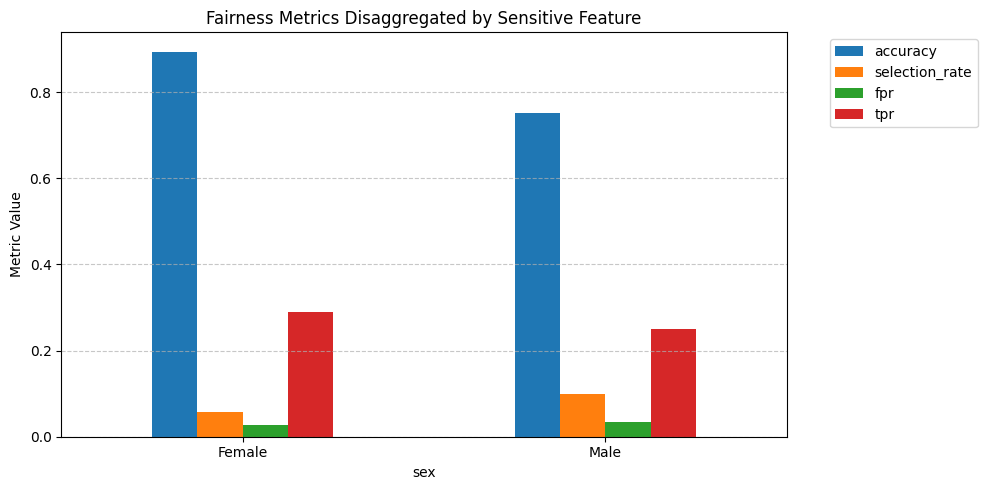

In [5]:
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
import matplotlib.pyplot as plt

# Defining dictionary of metrics to audit
metrics_dict = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'fpr': false_positive_rate,
    'tpr': true_positive_rate
}

# Constructing MetricFrame across sensitive groups
metric_frame = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test
)

print("=== Overall Metrics ===")
print(metric_frame.overall)
print("\n=== Metrics By Demographic Group ===")
print(metric_frame.by_group)

# Visualizing fairness metrics using bar plots
metric_frame.by_group.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title("Fairness Metrics Disaggregated by Sensitive Feature")
plt.ylabel("Metric Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Explainability Analysis:

--- Top 10 Global Features (Model Weights) ---
                              Feature  Coefficient
5                      hours-per-week    -0.009544
0                                 age    -0.005781
32  marital-status_Married-civ-spouse     0.002797
34       marital-status_Never-married    -0.002794
51               relationship_Husband     0.002525
2                       education-num    -0.002195
52         relationship_Not-in-family    -0.001664
54             relationship_Own-child    -0.001480
9                   workclass_Private    -0.001408
25                  education_HS-grad    -0.001285


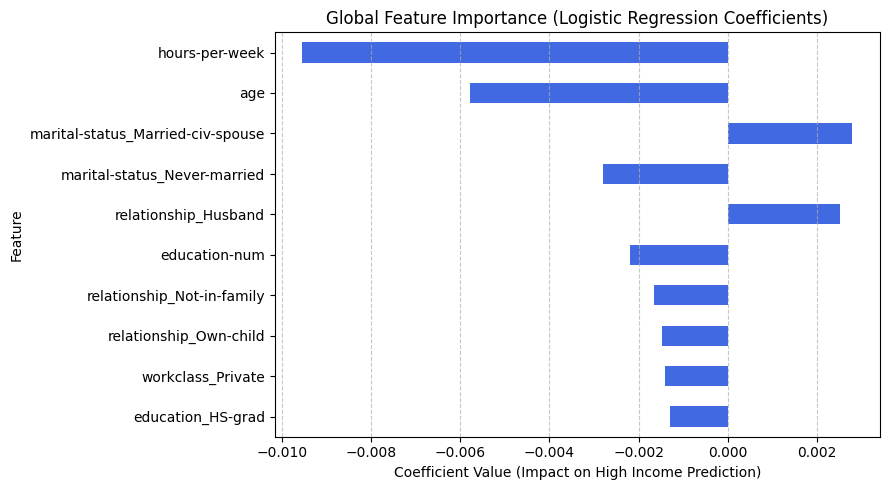


--- Local Explanation for Test Instance #0 ---
Predicted Probability of >50K Income: 0.5506
                                                             Feature  Value  \
capital-gain                                            capital-gain   2829   
hours-per-week                                        hours-per-week     40   
age                                                              age     40   
fnlwgt                                                        fnlwgt  27821   
education-num                                          education-num     11   
marital-status_Married-civ-spouse  marital-status_Married-civ-spouse   True   
relationship_Husband                            relationship_Husband   True   
workclass_Private                                  workclass_Private   True   
native-country_United-States            native-country_United-States   True   
race_White                                                race_White   True   

                                   Co

In [7]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("--- Top 10 Global Features (Model Weights) ---")
print(coefficients.head(10))

# Plot top global feature importances
plt.figure(figsize=(9, 5))
coefficients.head(10).set_index('Feature')['Coefficient'].plot(kind='barh', color='royalblue')
plt.title('Global Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on High Income Prediction)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Local Explainability
sample_idx = 0
sample_x = X_test.iloc[sample_idx]
sample_pred_prob = model.predict_proba(X_test.iloc[[sample_idx]])[0][1]

local_impact = pd.DataFrame({
    'Feature': X_train.columns,
    'Value': sample_x,
    'Coefficient': model.coef_[0],
    'Net_Impact': sample_x * model.coef_[0]
}).sort_values(by='Net_Impact', key=abs, ascending=False)

print(f"\n--- Local Explanation for Test Instance #{sample_idx} ---")
print(f"Predicted Probability of >50K Income: {sample_pred_prob:.4f}")
print(local_impact.head(10))